# Pràctica de l' Algoritme k-means amb el Dataset CarSeats
# Carlos Recaj Peraire i Daniel Suarez Angosto

## Objectiu de la pràctica
1. Aquest notebook il·lustra com utilitzar un model simple de machine learning per predir vendes de seients de cotxe en diferents localitzacions en funció de les altres variables al dataset de CarSeats (Venda de cadiretes per a nens al cotxe).
2. Aprendre a fer "Exploratory Data Analysis" (EDA),  per entendre la base de dades i el problema a resoldre.
4. Resoldre el problema fent servir una técnica simple i intuitiva, assignar la classe del exemple d'entrenament mes proper: Classificació amb K-Nearest Neighbors (KNN)
5. Aprendre a fer servir la llibreria de **pandas** per analitzar dades. Intuició: és un **Excel + SQL**.
   Important: Dedicar uns 10 minuts a llegir: [https://pandas.pydata.org/docs/user_guide/10min.html](https://pandas.pydata.org/docs/user_guide/10min.html)

---

## Descripció del problema:

El dataset **CarSeats** conté informació sobre les vendes  de cadiretes per a nens al cotxe en diferents llocs.
La base de dades de les Vendes de Seients de Cotxe per a Nens és un conjunt de dades simulades que conté les vendes de seients de cotxe per a nens en 400 botigues diferents. La base de dades prové del llibre: "An Introduction to Statistical Learning" [1].

La base de dades conté diverses variables que descriuen les característiques de les botigues i les vendes de seients, com ara el preu del seient, la ubicació de la botiga, la publicitat i altres factors que poden influir en les vendes. L'objectiu és analitzar aquestes dades per a comprendre quins factors són els més importants per a predir les vendes de seients per a nens i assesorar al usuari (imaginari) que ha encarregat l'estudi que estem fent.


---
| Variable | Descripció de variable |
|---|---|
| **Sales**:| Vendes unitàries (variable objectiu).
| **CompPrice**:| Preu cobrat pels **competidors** en cada localització.
| **Income**:| Ingressos mitjans a la zona.
| **Advertising**:| Pressupost de publicitat  de l'empresa.
| **Population**:| La població de la zona on es ven el seient de cotxe.
| **Price**:| El preu del seient de cotxe.
| **ShelveLoc**:| La ubicació del seient de cotxe a la prestatgeria (categòrica: 'Bad', 'Medium', 'Good').
| **Age**:| Edat mitjana de la població.
| **Education**:| Mitjana d'anys d'educació dels clients.
| **Urban**:| Si la localització és urbana o rural (categòrica: 'Yes', 'No').
| **US**:| Si la localització és als Estats Units (categòrica: 'Yes', 'No').

---

**Bibliografia**

[1]  James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in python. Springer Nature.

---

## <font color="red"><b>Exercici</b></font>
1. Per aclarir idees, redacta en un paràgraf un resum del tipus de base de dades i l'objectiu de la pràctica.

Es una  base de dades amb diferents variables com l'edat mitjana de la població o el preu del seient del cotxe i el número de ventes unitàries, que volem utilitzar per estudiar les vendes de les cadiretes amb l'arlgorisme k-means. 

2. Abans de començar a aplicar mètodes d'intel·ligència artificial, és important tenir una intuïció sobre com les variables observacionals poden influir en el resultat. A partir de la descripció de les variables, escriu breument una llista de variables que poden augmentar les vendes i una altra amb les que les poden disminuir. Proporciona una explicació d'una línia per justificar cada cas.

   **CompPrice**: Si es alt, faran que la gent ens prefereixi a nosaltres i per tant augmentaran
| **Income**: Si la gent cobra més diners, estarà disposada a gastar-se més diners 
| **Advertising**: Si gastem més en publicitat, la gent ens coneixerà més i les ventes haurien de pujar
| **Population**: Si hi ha més gent, hi haurà més probabilitat de que neixin més gent
| **Price**: Si el preu és alt la gent estarà menys disposada a comprar la cadireta 
| **ShelveLoc**: Contra millor posició més ventes haurien d'haver 
| **Age**: Una edat mitjana molt alta no afavorirà a la compra de cadiretes
| **Education**: Si hi ha més educació hi hauria d'haver més interés en comprar seguretat pels seus fills
| **Urban**: En una zona urbana hauria d'haver més gent i per tant més vente
| **US**: A Estats Units estaran més predisposats a gastar-se diners


# Esquema del procés de treball en Aprenentatge Automàtic.
* **Aprenentatge Automàtic** :en anglés Machine Learning.

<img src="procestreballAprenentatgeAutomatic.png" width="900" height="600">

# 1. Algoritme k-means: una introducció intuitiva.
## 1.2. Funcionament
### Explicació de l'algoritme k-means

a. Volem identificar representants de les observacions distribuïdes en un espai tridimensional $R^3$, on cada dimensió correspon a una característica específica: **Preu de compra** (CompPrice), **Ingressos mitjans a la zona** (Income) i **Pressupost de publicitat** (Advertising). Veure figura mes abaix.

b. Cada punt representat a la figura següent correspon a una observació individual, amb valors específics per a cadascuna de les dimensions mencionades.

c. L'algoritme de k-means té com a objectiu trobar "k" valors mitjans (anomenats centroides), que es poden entendre com a centres de massa. A la figura següent, aquests centroides es representen amb **cercles verds**. En aquest cas, hem identificat tres centroides.

d. L'espai es divideix assignant cada observació al centroide més proper. A la figura, aquesta assignació es visualitza mitjançant colors diferents que indiquen el centroide corresponent per a cada observació.  Cada grup assignat a un centroide és denomina **clúster**.

e. Existeix un algoritme iteratiu que s'encarrega de calcular els centroides. Aquest algoritme ajusta de manera successiva la posició dels centroides fins a aconseguir una distribució òptima.
 
<img src="Kmeans.jpg" width="600" height="600">

### 1.3. Explicació Intuïtiva del K-Means

K-Means és un algorisme que troba centres de massa, el procés es denomina *clustering* que agrupa punts de dades en un nombre predefinit de clústers $k$, es a dir **k centres de massa**. Funciona de manera iterativa per assignar punts de dades a clústers i trobar els millors centres dels clústers. A continuació, s’explica el procés de manera intuïtiva pas a pas:

1. **Escollir el Nombre de Clústers (\(k\))**  
   Decideix quants clústers vols dividir les teves dades.

2. **Inicialitzar els Centres dels Clústers (Centroides)**  
   - Selecciona \(k\) punts aleatoris del conjunt de dades per actuar com a centres inicials dels clústers.

3. **Assignar els Punts de Dades als Clústers**  
   - Per a cada punt de dada, calcula la seva **distància** a cada centroid.  
   - Assigna el punt al clúster amb el centroid més proper.

4. **Actualitzar els Centroides**  
   - Calcula la mitjana (centre) de tots els punts assignats a cada clúster.  
   - Mou el centroid a aquesta nova posició mitjana.

5. **Repetir**  
   - Repeteix els passos d'assignar punts als clústers i actualitzar els centroides fins que aquests deixin de canviar significativament (*convergència*) o fins a assolir un nombre màxim d’iteracions.

6. **Resultat Final**  
   Les assignacions finals de clústers i les posicions dels centroides.

Aquest procés ajuda a agrupar dades similars en clústers diferenciats, fent que cada grup comparteixi característiques comunes.


## <font color="red"><b>Exercici 1</b></font>
1. Per aclarir idees, redacta en un paràgraf una explició de com funciona  l`algoritme the k-means.

    Decidim en quantes "boles"/clusters volem dividir l'espai i els inicialitzem en uns valors centrals 
    En funció de les noves dades que iterem recalculem els centres del cluster 
     Repetim el procés fins que convergeixin els valors 

In [1]:
# Importem les llibreries necessàries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 2. Càrrega del Dataset
#### Explicació de que és un **DataFrame**.

* Analogía: funciona com una taula **excel**.
* Un **DataFrame** de la llibreria Pandas és una estructura de dades bidimensional, en forma de **taula**.
    * Cada fila i columna té etiquetes (indexos i noms de columnes, respectivament), per a l'accés, la manipulació i l'anàlisi de les dades.
    * Pot contenir diferents tipus de dades (numèrics, text, dates, etc.) en les seves columnes.
    * Funcionalitats: filtres, agregacions, transformacions, combinacions i visualitzacions.

In [2]:
# Carreguem el dataset
df = pd.read_csv("CarSeats.csv")  
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


# 3. Anàlisi exploratòria de dades (EDA)
## 3.1. Objectius de l'EDA:

###  Entendre millor l'estructura  de les dades.

L'Anàlisi Exploratòria de Dades (EDA) ajuda a  comprendre l'estructura de les bases de dades. 

###  Funcionalitats Essencials

L'EDA ens permet:

* **Entendre l'estructura i característiques de les dades**: 
  - Identificar el nombre i tipus de variables
  - Comprendre la distribució de les dades
  - Detectar la complexitat inherent del dataset

* **Identificar patrons, tendències i relacions**:
  - Descobrir correlacions entre variables
  - Observar comportaments sistemàtics
  - Anticipar possibles insights per a la modelització

* **Descobrir possibles anomalies o valors atípics**:
  - Localitzar dades inusuals o extremes
  - Avaluar l'impacte d'aquests valors en l'anàlisi
  - Decidir estratègies de tractament (eliminació, transformació)

* **Avaluar la qualitat i la integritat de les dades**:
  - Verificar la completesa del dataset
  - Detectar valors missing o inconsistents
  - Assegurar la fiabilitat de la font de dades


##  Terminología

* **Anàlisi Exploratòria de Dades :** Exploratory Data Analysis (EDA). S'utilitza per obtenir una comprensió inicial de les dades a través de mètodes visuals i estadístics.
* **Conjunt de dades:** Dataset. És una col·lecció de dades, generalment en format tabular, que s'utilitza per a l'anàlisi.
* **Estructura de les dades:** Data structure. Es refereix a la manera en què s'organitzen les dades, com ara taules, matrius o arbres.

### 3.2. Tipus de dades i presencia de valors no numèrics.
* *Justificació*:  El algoritme **k-means** requereix com a entrada valors en coma flotant (és a dir, de tipus 'float'), per què treballa en un espai vectorial $R^n$, on $n$ és el total de característiques per observació.

In [3]:
# Mostrem informació  del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


## <font color="red"><b>Exercici 2</b></font>
1. Enumeri els tipus de dades en que es representa el contingut de la base de dades. A quin tipus de dades pertany 'object'?
Pista: observar el resultat de df.head()

    float64, int64, i object que es un punter que en aquest cas va a Strings (dos d'ells Si/No i l'altre bad/medium/good)


### 3.3. Estadístiques de les variables numèriques.

El mètode `df.describe()` és una funció de la llibreria Pandas, que proporciona un resum estadístic de les columnes. Aquest resum inclou:

* **count:** El nombre de valors no nuls en cada columna.
* **mean:** La mitjana aritmètica dels valors.
* **std:** La desviació estàndard dels valors.
* **min:** El valor mínim.
* **25%:** El percentil 25 (el valor per sota del qual es troba el 25% dels valors).
* **50%:** El percentil 50 (la mediana).
* **75%:** El percentil 75 (el valor per sota del qual es troba el 75% dels valors).
* **max:** El valor màxim.

Aquesta informació  permet obtenir una primera visió general de les dades i identificar possibles anomalies o tendències.

In [4]:
# Mostrem estadístiques descriptives
df.describe().round(2)

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,7.50,124.98,68.66,6.64,264.84,115.80,53.32,13.90
std,2.82,15.33,27.99,6.65,147.38,23.68,16.20,2.62
min,0.00,77.00,21.00,0.00,10.00,24.00,25.00,10.00
25%,5.39,115.00,42.75,0.00,139.00,100.00,39.75,12.00
50%,7.49,125.00,69.00,5.00,272.00,117.00,54.50,14.00
75%,9.32,135.00,91.00,12.00,398.50,131.00,66.00,16.00
max,16.27,175.00,120.00,29.00,509.00,191.00,80.00,18.00


### 3.3.1 Formes de tres distribucions de probabilitats típiques.

#### Utilitzar aquestes figures com referència pels propers dos apartats.
   
**Cas Gaussià**

 <img src="ExplicacioGausiana.jpg" width="400" height="400">
 
 **Cas Laplacià**
 
   <img src="ExplicacioLaplaciana.jpg" width="400" height="400">
   
**Cas Uniforme**  

<img src="ExplicacioUniforme.jpg" width="400" height="400"> 


## 3.4. Comparació simulació de dades amb distribució empírica 
* Generem una simulació de dades amb valors similars a la distribució empírica, i comparem amb els valors: { min, 25%, 50%, 75%, max}

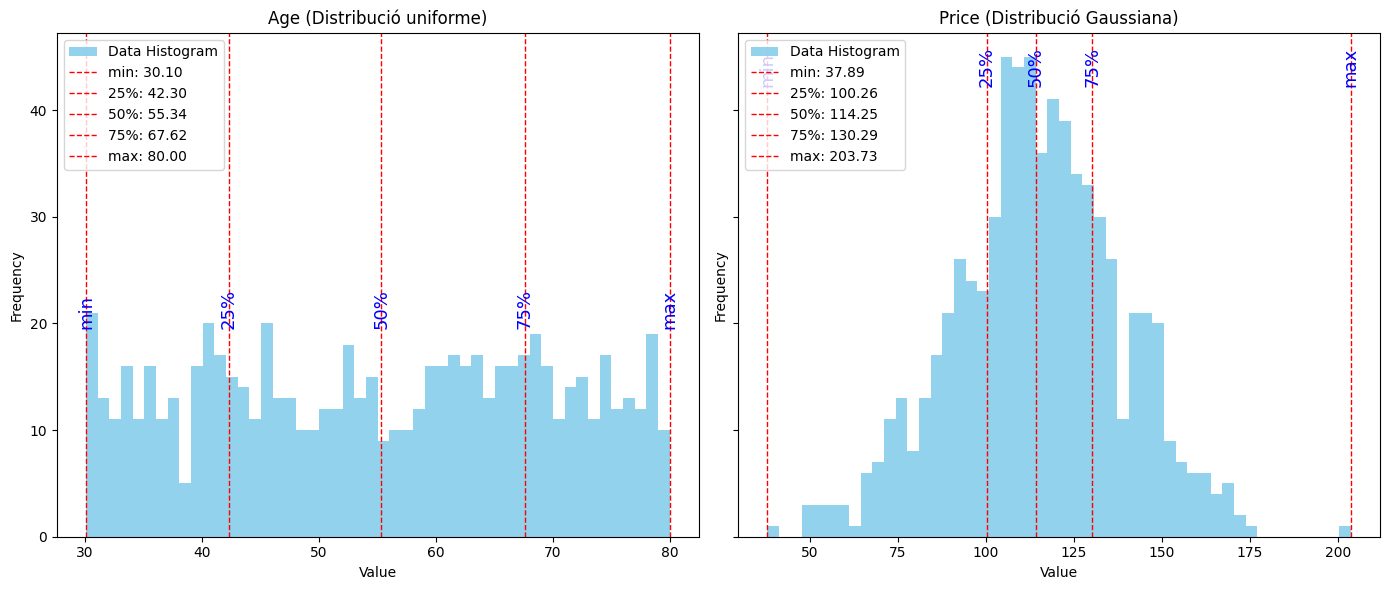

In [3]:
# Simulem les dades per a les distribucions Uniforme i Gaussiana
data_uniform = np.random.uniform(low=30, high=80, size=700)
data_gaussian = np.random.normal(loc=115, scale=25, size=700)

# Calculem les estadístiques
def compute_statistics(data):
    return {
        'min': np.min(data),
        '25%': np.percentile(data, 25),
        '50%': np.median(data),
        '75%': np.percentile(data, 75),
        'max': np.max(data),
    }
stats_uniform = compute_statistics(data_uniform)
stats_gaussian = compute_statistics(data_gaussian)

# Creació de subgràfics
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
titles = ['Age (Distribució uniforme)', 'Price (Distribució Gaussiana)']
datasets = [data_uniform, data_gaussian]
statistics = [stats_uniform, stats_gaussian]

# Plot histogrames i marca les estadístiques descriptives
for ax, data, stats, title in zip(axes, datasets, statistics, titles):
    ax.hist(data, bins=50, color='skyblue', alpha=0.9, label='Data Histogram')
    for stat_name, value in stats.items():
        ax.axvline(value, color='red', linestyle='--', linewidth=1, label=f'{stat_name}: {value:.2f}')
        ax.text(value, ax.get_ylim()[1] * 0.9, f'{stat_name}', rotation=90, color='blue', fontsize=13, ha='center')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## <font color="red"><b>Exercici 4</b></font>
1. Justifiqueu en un paragràf si la distribució  de les dades s'ajusta al model amb el qual hem generat les dades. **Expliqueu breument les differències entre distribució teórica i una realització**. Tingueu en compte els estadístics descriptius i les figures del apartat 3.3.1.

El de l'esquerra més o menys si que es uniforme però veiem que hi ha bastantes desviacions 

El de la dreta més o menys també veiem que és una gaussiana 

2. **Avançat i optatiu**: Examineu amb detall el codi que genera les gràfiques i expliqueu-lo. L'objectiu és que aprengueu trucs per fer presentacions intuïtives.

### 3.5. Histogrames de les variables numériques del  Dataset CarSeats
Complement a  la descripció en estadistics  { min, 25%, 50%, 75%, max}

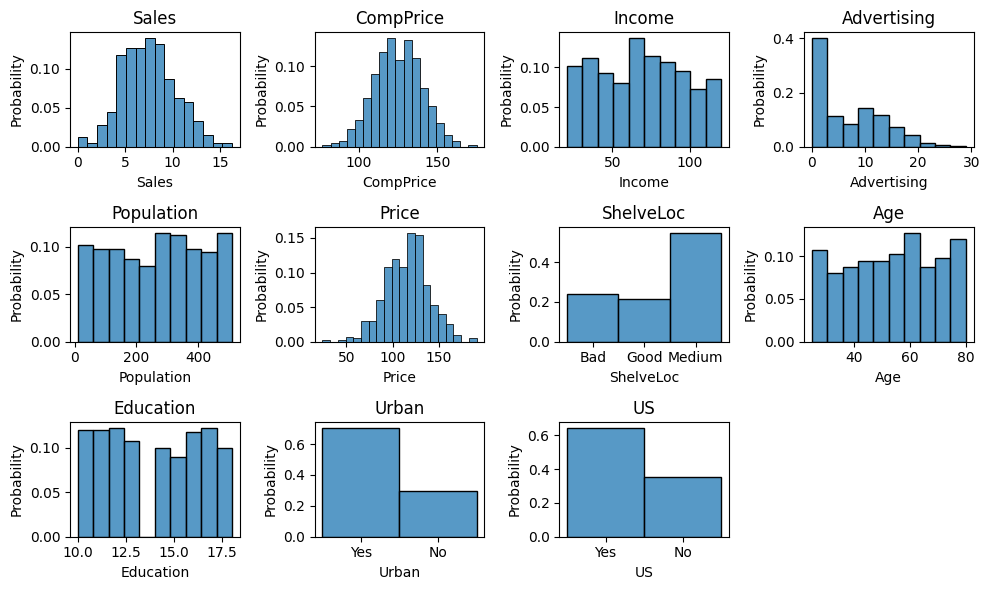

In [4]:
plt.figure(figsize=(10, 6))
for i, col in enumerate(df.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[col], kde=False, stat='probability',kde_kws={ 'bw_adjust': 02.5})  # Set color within 'kde_kws' dictionary
    plt.title(col)
plt.tight_layout()
plt.show()

## <font color="red"><b>Exercici 5</b></font>

1. Indiqui quin és la distribució de probabilitat de cada una de les variables:

| Variable      | Tipus de distribució de probabilitat                                       |
|--------------|-----------------------------------------------------------------------------|
| **Sales**    |  Gaussiana                                                                            |
| **CompPrice**|  Gaussiana                                                                           |
| **Income**   |  Uniforme                                                                            |
| **Advertising** |  Mitja Laplaciana (exponencial decreixent)                                                                     |
| **Population**| Uniforme                                                                           |
| **Price**    |  Gaussiana                                                                           |
| **ShelveLoc**|  Uniforme (poc uniforme)                                                                           |
| **Age**      |  Uniforme                                                                           |
| **Education**|  Uniforme                                                                           |
| **Urban**    |  Uniforme                                                                           |
| **US**       |  Uniforme                                                                           |
                                                                        |
   

### 3.6. Transformació de les variables categòriques en numèriques
* Objectiu proporcionar una tècnica ràpida per transformar en una línea de codi valors en un dataframe.

In [5]:
df = pd.read_csv("CarSeats.csv") 

# Transformació de les variables categòriques en numèriques
df['ShelveLoc'] = df['ShelveLoc'].map({'Bad': 0, 'Medium': 1, 'Good': 2})
df['Urban'] = df['Urban'].map({'No': 0, 'Yes': 1})
df['US'] = df['US'].map({'No': 0, 'Yes': 1})
df.describe().round(2)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,7.50,124.98,68.66,6.64,264.84,115.80,0.97,53.32,13.90,0.70,0.64
std,2.82,15.33,27.99,6.65,147.38,23.68,0.67,16.20,2.62,0.46,0.48
min,0.00,77.00,21.00,0.00,10.00,24.00,0.00,25.00,10.00,0.00,0.00
25%,5.39,115.00,42.75,0.00,139.00,100.00,1.00,39.75,12.00,0.00,0.00
50%,7.49,125.00,69.00,5.00,272.00,117.00,1.00,54.50,14.00,1.00,1.00
75%,9.32,135.00,91.00,12.00,398.50,131.00,1.00,66.00,16.00,1.00,1.00
max,16.27,175.00,120.00,29.00,509.00,191.00,2.00,80.00,18.00,1.00,1.00


## <font color="red"><b>Exercici 6</b></font>
1. Justifiqueu en un paràgraf en termes de distància euclidiana en el algorisme *k-means* per què s'ha fet aquesta transformació.
   Pista: **Es pot fer distància euclidea entre símbols**  
   (veure secció 1.3. Explicació Intuïtiva del K-Means, i la necesitat de calcular una distància).

   Ho fem perqué per poder calcular una distància, no podem utilitzar good o Yes per deteminar-la però en canvi sí que podem utilitzar valors numèrics assignats a cada observació assignant un valor a cada observació.

3. **Avançat i optatiu**: Examineu amb detall el codi que aplica el mètode "map" i expliqueu-lo. L'objectiu és que aprengueu trucs per fer transformacions de dades ràpides en python.

   Sabem que el mètode map ens aplica una funció a una llista de valors i així podem aplicar la funció sense haver de fer un bucle for.

### 3.7 Intuició sobre dependència entre variables (**scatter plot**) 
* Observar la correlació Vendes (Sales) amb Preu de competència,localització en la prestageria es pot entendres desde el punt de vista de com es relacionen les observacions.

*Per exemple, el scatter plot de `ShelveLoc` i `Sales` (figura següent a l'esquerra) crea un gràfic de dispersió on:
- L'eix X (eix horitzontal) representa els valors de la variable `ShelveLoc`.
- L'eix Y (eix vertical) representa els valors de la variable `Sales`.

Cada punt del gràfic correspon a una combinació de valors de `ShelveLoc` i `Sales` del dataset. Aquest gràfic ens ajuda a visualitzar si hi ha alguna relació entre la ubicació dels seients als prestatges i les vendes, en aquest cas es veu una tendència creixent.

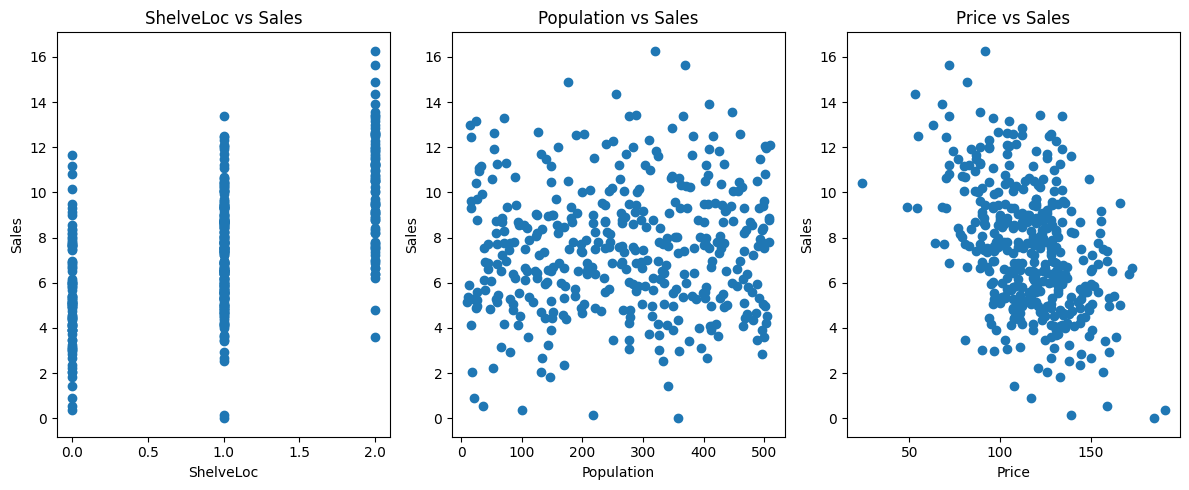

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
axs[0].scatter(df['ShelveLoc'], df['Sales'])
axs[0].set_title('ShelveLoc vs Sales')
axs[0].set_xlabel('ShelveLoc')
axs[0].set_ylabel('Sales')

axs[1].scatter(df['Population'], df['Sales'])
axs[1].set_title('Population vs Sales')
axs[1].set_xlabel('Population')
axs[1].set_ylabel('Sales')

axs[2].scatter(df['Price'], df['Sales'])
axs[2].set_title('Price vs Sales')
axs[2].set_xlabel('Price')
axs[2].set_ylabel('Sales')

plt.tight_layout()
plt.show()

## <font color="red"><b>Exercici 7</b></font>
1. Explicar en un paràgraf a partir de les gràfiques anteriors que significa en termes de vendes tenir:   
   * Correlació positiva: Que si augmenta el valor augmenten les vendes (ShelveLoc).
   * Correlació nul·la: No hi ha relació entre augment de valor de població i augment de vendes.
   * Correlació negativa: Si augmenta el valor, disminueixen les vendes (price).

**Nota:** Correlació és la pendent de la recta que explica la distribució.

3. **Avançat i optatiu**: Explicar el codi python anterior que representa els scatter plots.

## 4.0. Model d'estimació de les vendes via k-means.

1. Divisió de la Base de Dades en Entrenament i Test
2. Creació del model
3. Avaluació de les prestacions

### 4.1. Explicació de la Divisió de la Base de Dades en Entrenament i Test

Justificació:
1. Base d'entrenament: Serveix per crear el model i estimar els seus paràmetres.
2. Base de test: Serveix per veure les prestacions amb dades que no han influid en la construcció del model.

    * #### Avaluació del Model: 
    **Justificació:** La divisió permet avaluar el rendiment del model en dades que no ha vist durant l'entrenament. 
    
    Això proporciona una estimació més realista de com es comportarà el model en dades noves.


In [6]:
# Definim la variable objectiu (y) i les variables predictors (X)
X = df.drop(columns=["Sales"])
y = df["Sales"]

# Dividim en conjunts d'entrenament (80%) i test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrem la mida dels conjunts resultants
print(f"Mida del conjunt d'entrenament: {X_train.shape}")
print(f"Mida del conjunt de test: {X_test.shape}")


Mida del conjunt d'entrenament: (320, 10)
Mida del conjunt de test: (80, 10)


## <font color="red"><b>Exercici 7</b></font>
1. **Per aclarir idees**, redactar en un paràgraf explicant per qué es fa la divisió de la Base de Dades en Entrenament i Test.

Ho fem per poder evaluar els resultats del model entrenat sense utilitzar dades per entrenar que després farem serir per a comprobar perquè si no ens donaria uns resultats "perfectes" pel fet d'estar-ho comprobant amb les mateixes dades amb les que s'ha entrenat el model. 

D'aquesta manera amb train calculem els paràmetres del model (centroide i etiqueta) i amb train evaluem el model.


###  4.1.2 <font color="blue">**Nota**</font>: Per poder aplicar distància  euclidea cal un pas d'escalat.
#### <font color="red">**Importància**</font>:  Si no es fa, el sistema **no** funciona!!!.

### Fórmula de la estandarizació: La fórmula per a estandarditzar les dades és:
$z = \frac{(x - \mu)}{\sigma}$
on:
- $z$ és el valor estandarditzat
- $x$ és el valor original de la característica
- $\mu$ és la mitjana dels valors de la característica
- $\sigma$ és la desviació estàndard dels valors de la característica

#### Implementació: from sklearn.preprocessing import **StandardScaler**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train= scaler.fit_transform(X_train) #estandarizar

# Use the same scaler to transform the test data
X_test = scaler.transform(X_test) #estandarizar
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [8]:
X.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,138,73,11,276,120,0,42,17,1,1
1,111,48,16,260,83,2,65,10,1,1
2,113,35,10,269,80,1,59,12,1,1
3,117,100,4,466,97,1,55,14,1,1
4,141,64,3,340,128,0,38,13,1,0


In [9]:
X_train.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,-0.493529,1.117232,-0.379057,1.340795,-0.811724,0.061316,0.102151,0.067511,0.654654,0.75918
1,-0.946049,1.468701,-0.983284,0.940667,-2.042773,1.570632,-0.445699,1.224840,-1.527525,0.75918
2,-0.234947,0.344000,-0.379057,0.975161,0.589126,-1.448000,-0.445699,-1.475594,-1.527525,0.75918
3,0.799384,1.292966,0.527282,1.126933,1.692826,1.570632,1.136979,0.067511,0.654654,0.75918
4,0.670093,0.871204,-0.681170,-1.411809,0.122176,0.061316,-1.176165,-1.089818,0.654654,0.75918


## <font color="red"><b>Exercici Optatiu</b></font>
1. Donar una justificació de per què aquest procés pot millorar el calcul de la distància euclidea.
*   **Pista:** Compari X.head() amb X_train.head(). Al dividir per $\sigma$, s'eliminen dimensions, i.e. km, gram, cm són comparables.

Ens serveix per poder comparar mesures amb la mateixa magnitud i que totes afectin de la mateixa manera

### 4.2. Estimació de la Variable Sales Utilitzant K-Means

Esquema dels següents apartats l'algoritme k-means per crear un aproximador de la variable `Sales` utilitzant `X_train` com a entrada. Els passos són els següents:

1. **Importar les biblioteques necessàries**: Importem les biblioteques necessàries per a l'anàlisi.
2. **Ajustar el model k-means a `X_train`**: Ajustem el model k-means a les dades d'entrenament `X_train`.
3. **Predecir les etiquetes dels clústers per a `X_train`**: Predeim les etiquetes dels clústers per a les dades d'entrenament.
4. **Calcular la mitjana de `Sales` per a cada clúster**: Calculem la mitjana de `Sales` per a cada clúster.
5. **Utilitzar les mitjanes dels clústers per aproximar `Sales`**: Utilitzem les mitjanes dels clústers per aproximar els valors de `Sales`.
6. **Repetim per `X_test`**
7. **Comparem** prediccións de train i test vs valors reals.

#### 4.2.1 Importem les biblioteques necessàries
1. Llibreria que crea el objecte KMeans
2. Llibreria que permet avaluar les prestacions del model (MSE)

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

#### 4.2.2  Estructura de les dades:
 Assumim que X_train i y_train ja estan definits  de la forma següent

In [11]:
X_train.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,-0.493529,1.117232,-0.379057,1.340795,-0.811724,0.061316,0.102151,0.067511,0.654654,0.75918
1,-0.946049,1.468701,-0.983284,0.940667,-2.042773,1.570632,-0.445699,1.224840,-1.527525,0.75918
2,-0.234947,0.344000,-0.379057,0.975161,0.589126,-1.448000,-0.445699,-1.475594,-1.527525,0.75918
3,0.799384,1.292966,0.527282,1.126933,1.692826,1.570632,1.136979,0.067511,0.654654,0.75918
4,0.670093,0.871204,-0.681170,-1.411809,0.122176,0.061316,-1.176165,-1.089818,0.654654,0.75918


In [12]:
y_train.head()

3       7.40
18     13.91
202     4.10
250     9.16
274     7.22
Name: Sales, dtype: float64

#### 4.2.3  Ajustatem el model k-means a X_train amb el mètode 'fit'

In [13]:
kmeans = KMeans(n_clusters=30, random_state=42,n_init = 50)
kmeans.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",30
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",50
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


#### 4.2.4  Predicció de les **etiquetes** dels clústers per a X_train
* Comparació amb els valors reals
* **Observar**: K-means.predict retorna el **index** del centroide mes proper.
* En altres paraules:
    * kmeans.predict(X_train): Prediu les **etiquetes** de clúster per a les dades d'entrenament (X_train).
Després d'ajustar el model, el mètode `predict` permet assignar cada punt de dades a X_train al seu clúster més probable basant-se en els centroides apresos. Això proporciona una nova matriu que representa el clúster al qual pertany cada punt de dades.

In [14]:
cluster_labels = kmeans.predict(X_train)

## <font color="red"><b>Exercici 8</b></font>
1. **Per aclarir idees**, redactar en dos linies  que són els *cluster_labels* en la figura següent:
* <img src="Kmeans.jpg" width="300" height="300">

Els cluster_labels és l'etiqueta que li assignem i per tant, el número de vendes que assignem a cada clúster.

#### 4.2.4  Estimació **Vendes** per cada observació. 
* promig dels valors de Vendes en els elements de cada  **etiqueta** de cada clústers per a X_train

In [15]:
cluster_means = np.array([y_train[cluster_labels == i].mean() for i in range(kmeans.n_clusters)])

pd.DataFrame({'Valors de Vendes per centroide:':cluster_means}).round(1).T

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
Valors de Vendes per centroide:,8.8,5.9,7.6,7.6,6.0,9.9,6.6,8.0,9.2,7.0,...,6.1,8.4,10.0,6.9,5.6,7.6,9.9,6.3,5.5,8.9


## <font color="red"><b>Exercici 9</b></font>
1. **Per aclarir idees**, redactar en dos linies  que són els *cluster_means* en relació a la figura anterior.

Per tots els que estan dins del mateix clúster, calulem el promig de vendes de cada centroide. 

2. **Exercici avançat**: explicar la línea de codi anterior. El patró "list comprehension" és molt útil per escriure codi breu i clar.



#### 4.2.5  Assignació de  les mitjanes dels clústers a cada element de 'train' 

In [19]:
y_train_approx = cluster_means[cluster_labels]
pd.DataFrame({'Vendes predites:':y_train_approx,'Vendes reals:':y_train,'Diferència:':y_train_approx-y_train}).round(2).T

,3,18,202,250,274,63,248,301,108,90,...,214,121,399,20,188,71,106,270,348,102
Vendes predites:,7.05,11.63,6.26,9.97,6.03,6.03,6.03,7.60,5.90,5.53,...,7.60,7.05,7.55,5.58,5.90,6.08,6.13,9.52,9.25,6.13
Vendes reals:,7.40,13.91,4.10,9.16,7.22,8.47,5.36,7.41,3.47,5.33,...,4.83,11.67,9.71,6.41,8.07,6.50,0.16,11.99,12.57,5.30
Diferència:,-0.35,-2.28,2.16,0.81,-1.19,-2.44,0.67,0.19,2.43,0.20,...,2.77,-4.62,-2.16,-0.83,-2.17,-0.42,5.97,-2.47,-3.32,0.83


## <font color="red"><b>Exercici 10</b></font>
1. **Per aclarir idees**, redacti en dues linies com fer servir la 'Diferència' per establir la qualitat de l'aproximació.

Si la diferència és molt alta, ens estarem molt i l'estimació és pitjor.

#### 4.2.6 Error Quadràtic Mitjà (MSE)

L'Error Quadràtic Mitjà (*Mean Squared Error*, MSE) és una mètrica que mesura la mitjana dels quadrats de les diferències entre els valors reals i els valors predits. Aquesta mètrica s'utilitza per avaluar el rendiment d'un model de regressió, quantificant l'error entre les prediccions i les observacions reals.

- **Fórmula del MSE**:
  $ \text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2 $
  On:
  - $ y_i $ són els valors reals.
  - $ \hat{y}_i $ són els valors predits pel model.
  - $ n $ és el nombre d'observacions.
- **Interpretació**:
  - Un valor de MSE més petit indica que el model té un error menor.
  - Com que es calcula utilitzant el quadrat de les diferències, penalitza errors grans de manera més severa que els petits.


In [20]:
# Calcular l'error quadràtic mitjà de l'aproximació
mse = mean_squared_error(y_train, y_train_approx)
print(f'Error Quadràtic Mitjà: {mse:2.2f}')

pd.DataFrame({'Vendes predites:':y_train_approx,'Vendes reals:':y_train,'$Diferència^2$':(y_train_approx-y_train)**2}).round(2).T


Error Quadràtic Mitjà: 4.66


,3,18,202,250,274,63,248,301,108,90,...,214,121,399,20,188,71,106,270,348,102
Vendes predites:,7.05,11.63,6.26,9.97,6.03,6.03,6.03,7.60,5.90,5.53,...,7.60,7.05,7.55,5.58,5.90,6.08,6.13,9.52,9.25,6.13
Vendes reals:,7.40,13.91,4.10,9.16,7.22,8.47,5.36,7.41,3.47,5.33,...,4.83,11.67,9.71,6.41,8.07,6.50,0.16,11.99,12.57,5.30
$Diferència^2$,0.13,5.22,4.65,0.66,1.43,5.97,0.44,0.04,5.93,0.04,...,7.68,21.38,4.66,0.69,4.69,0.17,35.68,6.11,11.05,0.69


## <font color="red"><b>Exercici 11</b></font>
1. Per aclarir idees, redacti en dues linies com fer servir la <b>$Diferència^2$</b> en el codi anterior per establir la qualitat de l'aproximació.

Si la diferència és molt gran, el MSE augmentarà molt perquè al estar elevat al quadrat penalitza encara més els valors de diferència gran. El que ens interessa per tenir una bona qualitat és tenir un MSE baix, en aquest cas més baix que en l'anterior.

#### 4.2.6  Repetim el procediment per la base de test

In [16]:
# Predeir les etiquetes dels clústers per a X_test
cluster_labels_test = kmeans.predict(X_test)

# Utilitzar les mitjanes dels clústers per aproximar Sales per a X_test
y_test_approx = cluster_means[cluster_labels_test]

# Calcular l'error quadràtic mitjà de l'aproximació en les dades de prova
mse_test = mean_squared_error(y_test, y_test_approx)

print(f'Error Quadràtic Mitjà (TEST): {mse_test:2.2f}')
pd.DataFrame({'Vendes predites:':y_test_approx,'Vendes reals:':y_test,'$Diferència^2$':(y_test_approx-y_test)**2}).round(2).T

Error Quadràtic Mitjà (TEST): 8.53


,209,280,33,210,93,84,329,94,266,126,...,320,140,5,45,388,246,227,369,176,289
Vendes predites:,7.57,9.25,8.94,6.26,6.59,4.59,8.79,6.03,9.99,7.55,...,7.55,5.58,9.90,8.55,7.60,7.35,7.55,9.25,6.26,5.58
Vendes reals:,3.02,2.86,8.77,4.36,8.86,2.23,11.27,8.39,9.10,11.27,...,5.86,6.03,10.81,4.56,8.14,6.90,8.69,10.26,5.61,8.75
$Diferència^2$,20.68,40.79,0.03,3.60,5.16,5.58,6.17,5.59,0.78,13.83,...,2.86,0.21,0.83,15.92,0.29,0.20,1.30,1.03,0.42,10.07


## <font color="red"><b>Exercici 12</b></font>
1. Comparar el MSE de train i test. Explicar en dos linies per qué un és mes gran que l'altre.  

Evidentment, notem que el MSE de test és molt més gran que la de train, pràcticament del doble. Això és degut a que quan calculem el MSE amb les vendes que hem entrenat l'algoritme la diferencia entre VENDES REALS i VENDES PREDITES es menor, mentre que en el cas de test la diferencia es major.

2. Quina informació proporciona el MSE de test? (una linea)

Ens proporciona un valor de com variarà en mitja el estimador entre el valor real i el estimat. 

#### 4.2.7 Diagrama de dispersió de valor predit vs valor real  

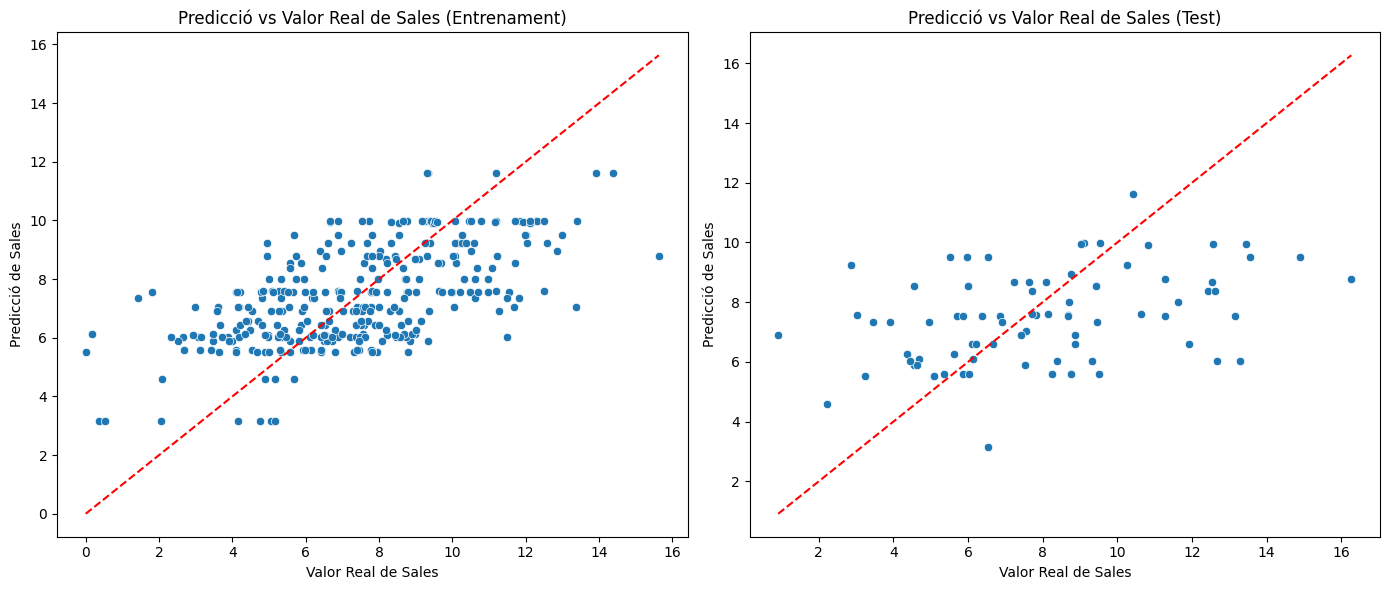

In [22]:
# Crear una figura amb dos subplots costat a costat
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Gràfic de dispersió per a les dades d'entrenament
sns.scatterplot(x=y_train, y=y_train_approx, ax=axs[0])
axs[0].plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--')
axs[0].set_title('Predicció vs Valor Real de Sales (Entrenament)')
axs[0].set_xlabel('Valor Real de Sales')
axs[0].set_ylabel('Predicció de Sales')

# Gràfic de dispersió per a les dades de prova
sns.scatterplot(x=y_test, y=y_test_approx, ax=axs[1])
axs[1].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
axs[1].set_title('Predicció vs Valor Real de Sales (Test)')
axs[1].set_xlabel('Valor Real de Sales')
axs[1].set_ylabel('Predicció de Sales')

# Ajustar el disseny
plt.tight_layout()

# Mostrar els gràfics
plt.show()

## <font color="red"><b>Exercici 13</b></font>
1. Expliqui en una linea, quina hauria de ser la relació entre el valor real i el predit?
   **Nota:** Hi ha un problema amb la distància euclidea. La solució es donarà en una pràctica futura.

   Hauria de ser el més petit possible, idealment 0. 

2. Perquè els valors es distribueixen en bandes?

   Perquè tindrem la mateixa estimació per valor amb una desviació positiva o una desviació negativa



#### 4.2.7  Analisi dels centroides

In [17]:
centroids = kmeans.cluster_centers_
df = pd.DataFrame(centroids.round(1), columns=X_train.columns)
df['Sales'] = cluster_means.round(1)
df_sorted = df.sort_values(by='Sales')
df_sorted.index.name = 'Index del Cluster'
df_sorted

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Sales
Index del Cluster,,,,,,,,,,,
15,0.6,0.1,-0.4,-0.7,1.6,-1.4,-1.5,0.5,0.7,-0.7,3.1
18,-0.1,0.0,-0.9,-1.3,-0.1,-1.4,-0.4,1.0,-1.5,-0.9,4.6
28,0.2,-0.7,-1.0,0.9,0.5,0.1,-0.1,-0.3,-1.2,-1.3,5.5
24,0.7,-0.7,0.3,0.7,0.7,-0.7,-0.7,0.9,0.5,0.8,5.6
1,-0.5,0.1,-0.9,0.8,-0.5,-0.4,0.8,0.7,0.7,-1.3,5.9
4,-0.0,0.7,0.0,-0.8,0.1,-0.5,0.5,-0.7,0.7,0.8,6.0
17,1.5,-0.3,-0.2,-1.3,1.3,0.2,0.5,0.4,-1.3,0.5,6.1
20,-0.8,-0.8,-0.8,-0.2,-0.7,-0.1,0.7,0.8,-1.5,-1.3,6.1
27,0.4,0.9,-0.0,0.6,0.4,-1.4,-0.7,-1.3,-1.2,0.5,6.3


#### 4.2.7.1 **Analisi dels Clústers**: Veurem si hi han relacions entre les variables en els centroides.

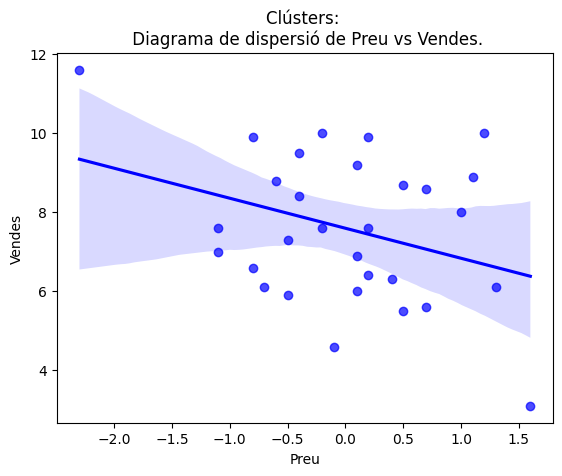

In [24]:
sns.regplot(data=df_sorted, x='Price', y='Sales', color='blue', scatter_kws={'alpha': 0.7})

# Add labels and title
plt.xlabel('Preu')
plt.ylabel('Vendes')
plt.title('Clústers: \n Diagrama de dispersió de Preu vs Vendes.')

# Show plot
plt.show()

## <font color="red"><b>Exercici 14</b></font>
1. Expliqui en un paràgraf, com interpreta la relació preu vendes.

Veiem el que hem vist abans de que la correlació entre preu i vendes és negativa i per tant els clústers també segueixen aixó 

2. En una linea, quin és el signe de $r_{Preu ,Vendes}$

Negatiu

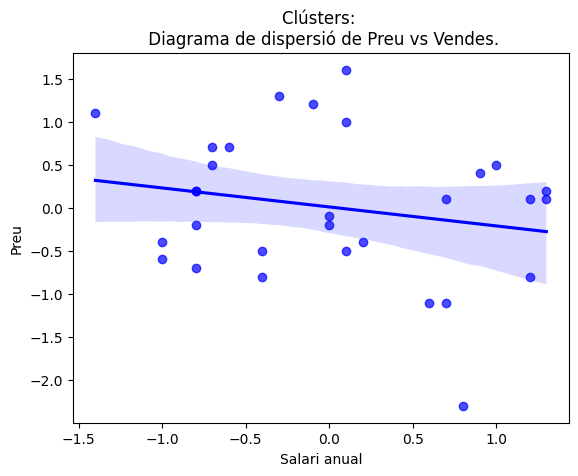

In [18]:
#Income	Advertising	Population	Price
sns.regplot(data=df_sorted, x='Income', y='Price', color='blue', scatter_kws={'alpha': 0.7})

# Add labels and title
plt.xlabel('Salari anual')
plt.ylabel('Preu')
plt.title('Clústers: \n Diagrama de dispersió de Preu vs Vendes.')

# Show plot
plt.show()

## <font color="red"><b>Exercici 15</b></font>
1. Expliqui en un paràgraf, com interpreta la relació Salari anual i  preu. 

  Pista: Sentit comú, és fiable?

  Veiem que no segueix cap patró massa fiable, ja que son variables incorrelades  
  
2. En una linea, quin és el valor probable de $r_{Salari anual ,  preu}$

Veiem que el pendent és tan petit que és pràcticament 0 


### 4.3. Gràfics de Barres per Clústers seleccionats per vendes.

**Utilitat:** Creat tipologies de elements de la base de dades.
Part més útil del mètode.


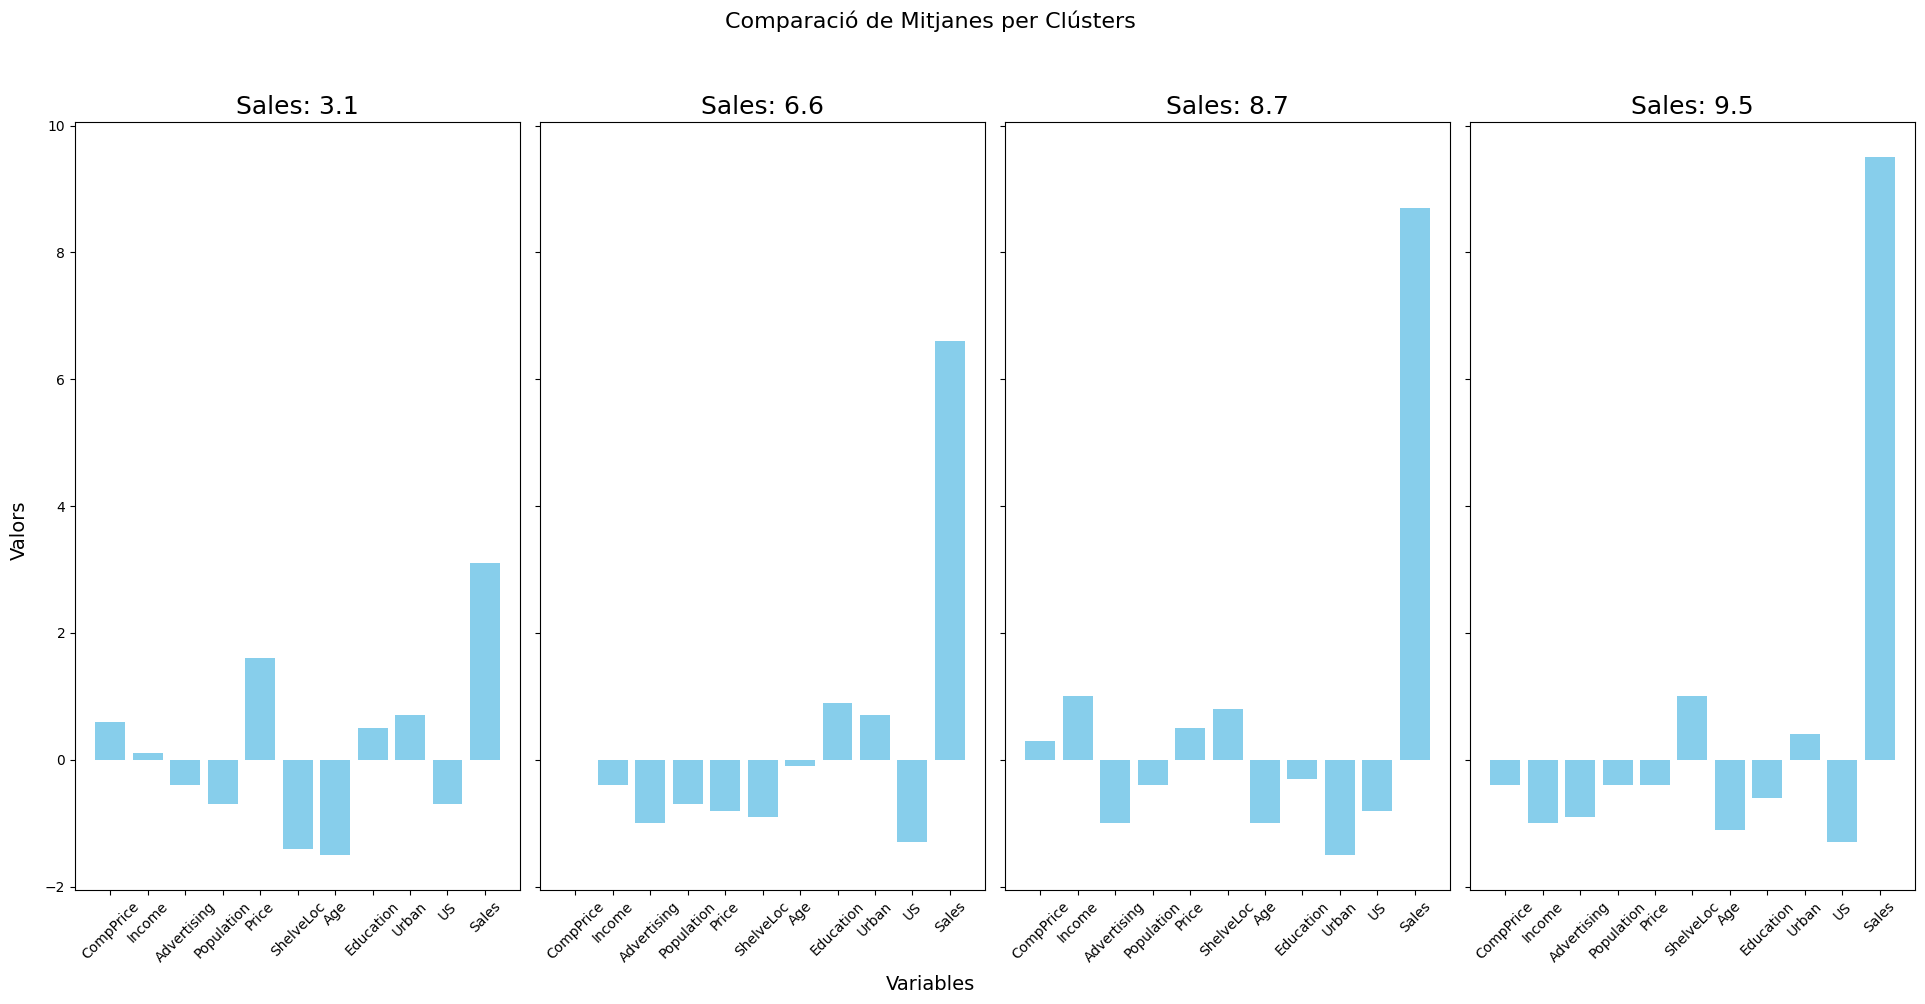

In [26]:
selected_clusters_T = df_sorted.iloc[[0,10,20,24]].T
# Crear una figura per als bar plots
fig, axs = plt.subplots(nrows=1, ncols=len(selected_clusters_T.columns), figsize=(20, 10), sharey=True)

# Iterar per cada variable i fer el bar plot
for i, cluster in enumerate(selected_clusters_T.columns):
    axs[i].bar(selected_clusters_T.index, selected_clusters_T[cluster], color='skyblue')
    axs[i].set_title(f'Sales: {selected_clusters_T.loc['Sales',cluster]}', fontsize=18)
    axs[i].tick_params(axis='x', rotation=45)

# Afegir etiquetes comunes per a tots els subplots
fig.text(0.5, 0.04, 'Variables', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Valors', va='center', rotation='vertical', fontsize=14)

# Ajustar la distribució dels subplots
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.suptitle('Comparació de Mitjanes per Clústers', fontsize=16, y=1.02)
plt.show()

## <font color="red"><b>Exercici 16</b></font>
Els clústers estan ordenats per valor de vendes.
1. Expliqui en un paràgraf, quina tipologia pot extreure de cada centroide i com es poden comparar.

Sales = 3.1: 
    Una població jove i un mal posicionament del producte i a un preu alt, afecten negativament a les ventes a pesar que sigui una zona urbana. Tampoc tenen massa publicitat, a una zona sense moltissima població i tenen una competència força alta. 

Sales = 6.6 
    Tenen un posicionament dolent, amb pitjor income i menys publicitat, però a diferència d'abans, amb força menys competència i un preu substancialment menor, a part de més edat mitjana, major educació i menys mercat de Estats Units i per aixó venen més que al cas anterior

Sales = 8.7 
    Ara estem en un cas amb més competència, però a una zona amb bastants ingressos, un preu elevat però un bastant bon posicionament en una zona molt més rural que als casos anteriors i una edat mitjana baixa i a una zona rural. Amb tot aixó, tenim unes vendes bastant altes. 

Sales = 9.5
    Ara baixa tot excepte el ShelveLoc i urban, però en canvi pujen les vendes. Per tant amb aquest punt i l'anterior podem determinar que el posicionament en el que es trobi la cadireta es decisiu. 



## <font color="Blue"><b>Informe Final i Recomanacions</b></font>
1. Informe on es relaciona la informació obtinguda amb l'estudi fet amb l'EDA amb els resultats obtinguts pel mètode de machine learning.

2. Recomanacions per millorar el sistema i implementar-lo.


Final Report P1: Pràctica de l' Algoritme k-means amb el Dataset CarSeats

En aquest informe analitzarem l’evolució de les vendes de cadiretes de cotxe en funció de certes variables amb l’algorisme k-means. Comencem fent l’EDA analitzant com son les variables a tenir en compte i ens adonem que son 7 int64, 3 strings (2 Yes/No, 1 Bad, Medium, Good) i 1 float64. La variable a estimar és un float amb distribució gaussiana i les altres tenen distribucions: 6 uniformes, 2 gaussianes i  1 mitja Laplaciana. Especificament:

| Variable      | Tipus de distribució de probabilitat                                       |
|--------------|-----------------------------------------------------------------------------|
| **Sales**    |  Gaussiana                                                                            |
| **CompPrice**|  Gaussiana                                                                           |
| **Income**   |  Uniforme                                                                            |
| **Advertising** |  Mitja Laplaciana (exponencial decreixent)                                                                     |
| **Population**| Uniforme                                                                           |
| **Price**    |  Gaussiana                                                                           |
| **ShelveLoc**|  Uniforme (poc uniforme)                                                                           |
| **Age**      |  Uniforme                                                                           |
| **Education**|  Uniforme                                                                           |
| **Urban**    |  Uniforme                                                                           |
| **US**       |  Uniforme                                                                           |

Després de transformar les variables categòriques a numèriques, seguim amb l’anàlisis de les dades i veiem que hi ha una correlació positiva entre ShelveLoc i Sales, nula correlació entre Population i Sales i correlació negativa entre Price i Sales, cosa que significa que si les cadiretes es troben millor posicionades, augmenten les vendes, que la població no varia el número de vendes i que un increment de preu fa baixar les unitats venudes. 

Fem la separació del dataset entre train i test i les estandaritzacions adients, perquè totes les variables passin a tenir una importància equitativa i fem l’entrenament. Amb el model entrenat calculem el MSE per veure que no tenim unes grans desviacions. 

Quan analitzem els clústers obtinguts comprovem que les correlacions o incorrelacions trobades a dalt s’han mantingut als clústers. Després d’analitzar diferents clústers, veiem que les variables que ens afecten més són clarament un bon posicionament del producte que ens afecta molt positivament al augment de les vendes així com no tenir massa competència i un preu baix. Una mitjana d’edat baixa no sembla afavorir massa a la venda de cadiretes, sinó més bé tot el contrari, especialment combinat amb un preu alt. Per últim destacar que tot i que podria semblar contraintuitiu, estar un una zona rural pot ser positiu en combinació amb una competència no massa alta i uns ingressos prou bons. 

En conclusió els principals punts per millorar les vendes són un bon posicionament a la botiga, mantenint un baix preu en una zona amb no massa competència. 


 
